# DATA OVERVIEW AND EDA

## 1: Project Overview
This notebook explores the processed Maji Ndogo agricultural dataset to understand its structure, assess data quality, examine the distribution of variables, and identify relationships between agricultural, environmental, and weather-related factors that influence crop productivity. The insights from this analysis will guide subsequent statistical analysis and predictive modeling.

## 2: Objectives

This notebook aims to:

- Understand the structure of the processed dataset.
- Assess overall data quality.
- Explore the distribution of numerical and categorical variables.
- Identify potential outliers and missing values.
- Investigate relationships between explanatory variables and crop yield.
- Generate insights that will guide statistical analysis and machine learning.

## 2: Import Libraries

In [1]:
import os
os.chdir("..")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.pipeline import create_final_dataset
from src.exploratory_data_analysis import  ExploratoryDataAnalysis

## 3: Load Dataset

In [3]:
eda = ExploratoryDataAnalysis()

2026-07-22 17:38:32 | src.exploratory_data_analysis | INFO | EDAHelper initialized


In [4]:
df = create_final_dataset()

2026-07-22 17:38:35 | src.data_ingestion | INFO | Successfully connected to: sqlite:///data/Maji_Ndogo_farm_survey_small.db
2026-07-22 17:38:35 | src.data_ingestion | INFO | Query executed. Rows: 5654
2026-07-22 17:38:35 | src.field_data_processor | INFO | SQL data is sucessfully loaded into DataFrame.
2026-07-22 17:38:35 | src.field_data_processor | INFO | Swapped columns: Annual_yield with Crop_type
2026-07-22 17:38:35 | src.field_data_processor | INFO | Converted negative elevation values to absolute as per project specification
2026-07-22 17:38:35 | src.field_data_processor | INFO | Mispelled names and extra whitespaces were found and got fixed
2026-07-22 17:38:35 | src.data_ingestion | INFO | Attempting to read CSV from: https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Maji_Ndogo/Weather_data_field_mapping.csv
2026-07-22 17:39:06 | src.data_ingestion | INFO | Successfully read CSV: 5654 rows, 3 columns
2026-07-22 17:39:06 | src.field_data_processor | INFO | Renamed 

In [5]:
def inspect_dataset(df):
    """
    This function provides a comprehensive overview of the dataset by displaying:
    - The first 5 rows (to understand column structure and data types)
    - The total number of rows and columns (to understand dataset size)
    - 5 random samples (to see data distribution without bias)
    _ The column structure and its data types/composition
    """
    return {
        'head': df.head(),
        'rows': df.shape[0],
        'columns': df.shape[1],
        'sample': df.sample(5, random_state=42),
        'info': df.info()
    }

inspection = inspect_dataset(df)

print(f"Rows: {inspection['rows']}")
print(f"Columns: {inspection['columns']}")
display(inspection['head'])
display(inspection['sample'])
display(inspection ['info'])

<class 'pandas.DataFrame'>
RangeIndex: 5654 entries, 0 to 5653
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Field_ID                 5654 non-null   int64  
 1   Elevation                5654 non-null   float64
 2   Latitude                 5654 non-null   float64
 3   Longitude                5654 non-null   float64
 4   Location                 5654 non-null   str    
 5   Slope                    5654 non-null   float64
 6   Field_Rainfall           5654 non-null   float64
 7   Min_temperature_C        5654 non-null   float64
 8   Max_temperature_C        5654 non-null   float64
 9   Ave_temps                5654 non-null   float64
 10  Soil_fertility           5654 non-null   float64
 11  Soil_type                5654 non-null   str    
 12  pH                       5654 non-null   float64
 13  Field_Pollution_Level    5654 non-null   float64
 14  Plot_size                5654 non-n

,Field_ID,Elevation,Latitude,Longitude,Location,Slope,Field_Rainfall,Min_temperature_C,Max_temperature_C,Ave_temps,...,pH,Field_Pollution_Level,Plot_size,Annual_yield,Crop_type,Standard_yield,Weather_station_ID,Station_Pollution_Level,Station_Rainfall,Temperature
0,40734,786.05580,-7.389911,-7.556202,Rural_Akatsi,14.795113,1125.2,-3.1,33.1,15.00,...,6.169393,0.085267,1.3,0.751354,cassava,0.577964,4,0.128261,1200.183505,13.188571
1,30629,674.33410,-7.736849,-1.051539,Rural_Sokoto,11.374611,1450.7,-3.9,30.6,13.35,...,5.676648,0.399684,2.2,1.069865,cassava,0.486302,0,0.352791,1575.953750,13.403900
2,39924,826.53390,-9.926616,0.115156,Rural_Sokoto,11.339692,2208.9,-1.8,28.4,13.30,...,5.331993,0.358029,3.4,2.208801,tea,0.649647,0,0.352791,1575.953750,13.403900
3,5754,574.94617,-2.420131,-6.592215,Rural_Kilimani,7.109855,328.8,-5.8,32.2,13.20,...,5.328150,0.286687,2.4,1.277635,cassava,0.532348,1,0.257333,577.383910,12.998899
4,14146,886.35300,-3.055434,-7.952609,Rural_Kilimani,55.007656,785.2,-2.5,31.0,14.25,...,5.721234,0.043190,1.5,0.832614,wheat,0.555076,1,0.257333,577.383910,12.998899


,Field_ID,Elevation,Latitude,Longitude,Location,Slope,Field_Rainfall,Min_temperature_C,Max_temperature_C,Ave_temps,...,pH,Field_Pollution_Level,Plot_size,Annual_yield,Crop_type,Standard_yield,Weather_station_ID,Station_Pollution_Level,Station_Rainfall,Temperature
4816,9189,144.83813,-12.337162,-7.015649,Rural_Hawassa,8.106139,1562.8,-8.6,36.3,13.85,...,5.572066,0.001636,4.4,1.963674,wheat,0.446290,2,0.043858,1690.955324,13.179717
5096,34107,491.45853,-1.068423,-3.988548,Rural_Kilimani,7.534660,466.3,-6.4,32.3,12.95,...,5.098073,0.019206,4.0,2.603085,potato,0.650771,3,0.238190,905.191397,13.256779
4706,6072,796.54120,-1.618118,-0.992979,Rural_Kilimani,23.671692,1467.5,-2.7,28.6,12.95,...,5.423997,0.057128,1.8,0.956311,cassava,0.531284,3,0.238190,905.191397,13.256779
1499,29418,816.13230,-3.767334,-2.560585,Rural_Kilimani,11.226282,983.7,-3.0,28.9,12.95,...,6.691951,0.391307,4.0,2.065718,wheat,0.516429,3,0.238190,905.191397,13.256779
3544,35101,688.56550,-4.492750,-7.623772,Rural_Kilimani,14.173515,555.1,-4.5,31.6,13.55,...,4.938555,0.333970,1.8,1.000303,potato,0.555724,1,0.257333,577.383910,12.998899


None

## 4: Data Quality Assessment

Before performing exploratory analysis, we evaluate the quality of the dataset by checking:

- Missing values
- Duplicate records
- Data types
- Invalid values
- Consistency of categorical variables
- Potential outliers

In [6]:
def quality_assesment(df) -> pd.DataFrame |  None:
    """
    Print a quality assessment of the DataFrame.
    """
  
    print("DATA QUALITY ASSESSMENT")
    
    missing_counts = df.isnull().sum()
    missing_values = missing_counts[missing_counts > 0]
    
    print("\n MISSING VALUES:")
    if len(missing_values) == 0:
        print("No missing values found!")
    else:
        for col, count in missing_values.items():
            pct = (count / len(df) * 100)
            print(f"  {col:20} | {count:5} missing ({pct:5.1f}%)")
    
    duplicate_count = df.duplicated().sum()
    
    print("\nDUPLICATE RECORDS:")
    if duplicate_count == 0:
        print("No duplicate rows found!")
    else:
        print(f"  Found {duplicate_count} duplicate rows ({duplicate_count/len(df)*100:.1f}%)")

    print("\n DATA TYPE COUNTS:")
    data_type_count = df.dtypes.value_counts()
    return data_type_count


quality_assesment(df)

DATA QUALITY ASSESSMENT

 MISSING VALUES:
No missing values found!

DUPLICATE RECORDS:
No duplicate rows found!

 DATA TYPE COUNTS:


float64    17
str         3
int64       2
Name: count, dtype: int64

In [ ]:
def get_categorical_columns(df) -> pd.DataFrame:

    """
    Identifies categorical columns in the DataFrame.
    """
    columns = df.select_dtypes(str).columns.to_list()
    categorical_columns = pd.DataFrame(columns, columns=["categorical_columns"])
    return categorical_columns
get_categorical_columns(df)

,categorical_columns
0,Location
1,Soil_type
2,Crop_type


In [ ]:
def list_categorical_values(df, column) -> pd.DataFrame:
    """
    This method lists unique values of categorical variables
    """
    unique_values = pd.DataFrame(df[column].unique(), columns=[column])
    return unique_values
list_categorical_values(df, "Location")

,Location
0,Rural_Akatsi
1,Rural_Sokoto
2,Rural_Kilimani
3,Rural_Hawassa
4,Rural_Amanzi


In [9]:
list_categorical_values(df, "Soil_type")

,Soil_type
0,Sandy
1,Volcanic
2,Loamy
3,Silt
4,Peaty
5,Rocky


In [23]:
def get_numeric_columns(df, exclude=None) -> list:
    """
    Gets all columns that are numeric except specified identifiers.
    """
    if exclude is None:
        exclude = ["Weather_station_ID", "Field_ID"]
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [col for col in numeric_cols if col not in exclude]
    return numeric_cols

numeric_cols = get_numeric_columns(df)
display(numeric_cols)

['Elevation',
 'Latitude',
 'Longitude',
 'Slope',
 'Field_Rainfall',
 'Min_temperature_C',
 'Max_temperature_C',
 'Ave_temps',
 'Soil_fertility',
 'pH',
 'Field_Pollution_Level',
 'Plot_size',
 'Annual_yield',
 'Standard_yield',
 'Station_Pollution_Level',
 'Station_Rainfall',
 'Temperature']

In [25]:
def summary_statistics(df, numeric_cols) -> pd.DataFrame:
    """
    Gets the descriptive/summary statistics of all numeric variables
    numeric unique identifiers
    """

    numeric_stats = df.describe().T
    return numeric_stats
descriptive_num_stats = summary_statistics(df, numeric_cols)
descriptive_num_stats

,count,mean,std,min,25%,50%,75%,max
Field_ID,5654.0,22632.733817,13133.762515,1.000000e+00,11463.250000,22615.500000,34077.750000,45153.000000
Elevation,5654.0,637.790709,173.573934,3.591080e+01,525.611413,663.058585,764.299550,1122.252100
Latitude,5654.0,-7.026330,3.515839,-1.500904e+01,-9.674298,-7.205178,-4.182984,0.260756
Longitude,5654.0,-4.365755,2.706603,-1.001572e+01,-6.708209,-4.463785,-2.015527,1.696276
Slope,5654.0,11.742669,9.540599,9.731625e-02,4.860120,9.104626,15.953242,79.865960
Field_Rainfall,5654.0,1201.943244,499.782824,1.031000e+02,773.175000,1200.600000,1625.425000,2470.900000
Min_temperature_C,5654.0,-4.411956,1.534330,-9.700000e+00,-5.500000,-4.300000,-3.300000,-0.100000
Max_temperature_C,5654.0,30.857057,1.884682,2.450000e+01,29.600000,30.800000,32.100000,37.800000
Ave_temps,5654.0,13.222550,0.801636,1.025000e+01,12.700000,13.200000,13.750000,17.300000
Soil_fertility,5654.0,0.619308,0.044791,5.100000e-01,0.590000,0.620000,0.650000,0.820000


## 5: Target Variable: Standard Yield

**Standard Yield** is our target variable because it's the outcome we want to predict. All other columns (weather, soil, field characteristics) serve as features that might influence yield.

In [21]:
def single_variable_desc_statistics(df, column)-> pd.DataFrame:
    desc_stats = pd.DataFrame(df[column].describe())
    return desc_stats
single_variable_desc_statistics(df, "Standard_yield")

,Standard_yield
count,5654.000000
mean,0.534405
std,0.111806
min,0.170717
25%,0.460386
50%,0.528836
75%,0.599942
max,0.898037


## Data Quality Findings

- The dataset contains 5,654 observations and no missing values.
- No duplicate records were identified.
- Numerical variables are correctly typed.
- Categorical variables contain consistent labels after preprocessing.
- Standard_yield contains no impossible negative values.

## 6: Univariate Analysis

This section explores individual variables to understand their distributions, variability, and potential anomalies. Numerical variables are examined using descriptive statistics and visualizations, while categorical variables are analyzed through frequency distributions.

### 1: Summary statistics

In [26]:
summary_statistics(df, numeric_cols)

,count,mean,std,min,25%,50%,75%,max
Field_ID,5654.0,22632.733817,13133.762515,1.000000e+00,11463.250000,22615.500000,34077.750000,45153.000000
Elevation,5654.0,637.790709,173.573934,3.591080e+01,525.611413,663.058585,764.299550,1122.252100
Latitude,5654.0,-7.026330,3.515839,-1.500904e+01,-9.674298,-7.205178,-4.182984,0.260756
Longitude,5654.0,-4.365755,2.706603,-1.001572e+01,-6.708209,-4.463785,-2.015527,1.696276
Slope,5654.0,11.742669,9.540599,9.731625e-02,4.860120,9.104626,15.953242,79.865960
Field_Rainfall,5654.0,1201.943244,499.782824,1.031000e+02,773.175000,1200.600000,1625.425000,2470.900000
Min_temperature_C,5654.0,-4.411956,1.534330,-9.700000e+00,-5.500000,-4.300000,-3.300000,-0.100000
Max_temperature_C,5654.0,30.857057,1.884682,2.450000e+01,29.600000,30.800000,32.100000,37.800000
Ave_temps,5654.0,13.222550,0.801636,1.025000e+01,12.700000,13.200000,13.750000,17.300000
Soil_fertility,5654.0,0.619308,0.044791,5.100000e-01,0.590000,0.620000,0.650000,0.820000


### 2: Distribution plots

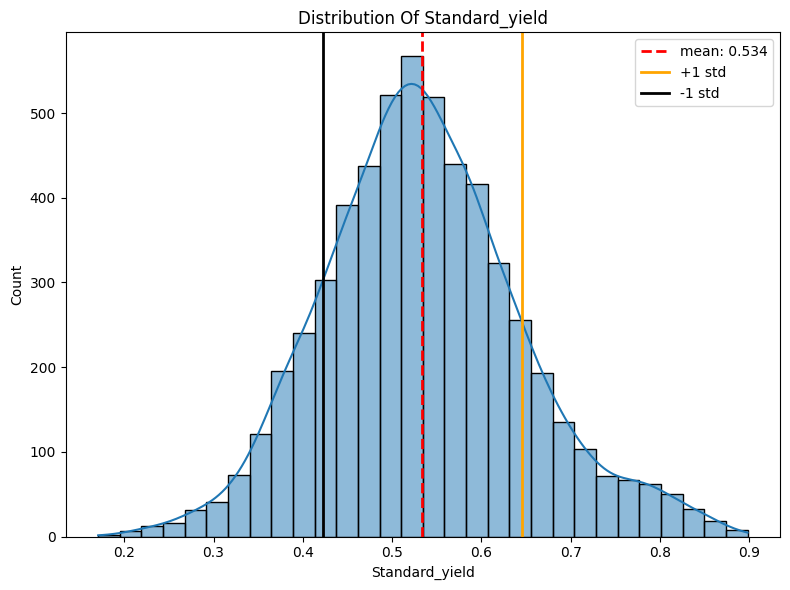

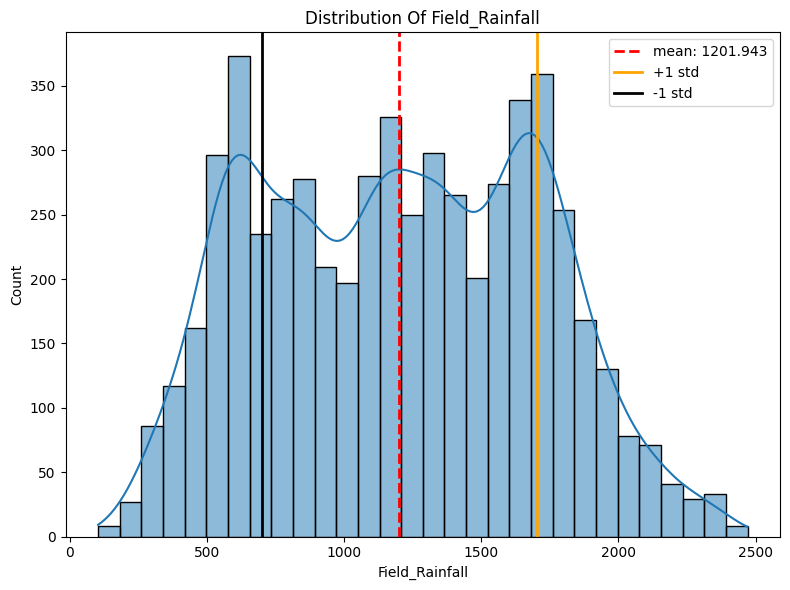

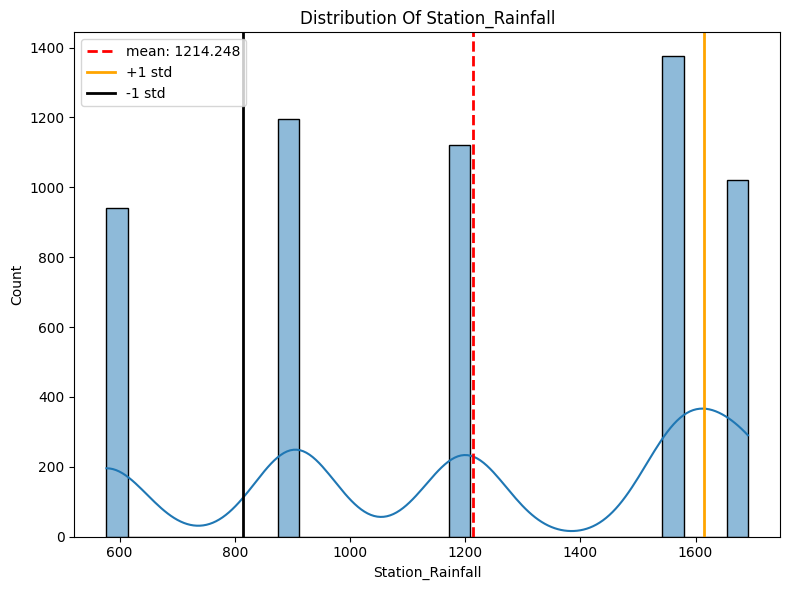

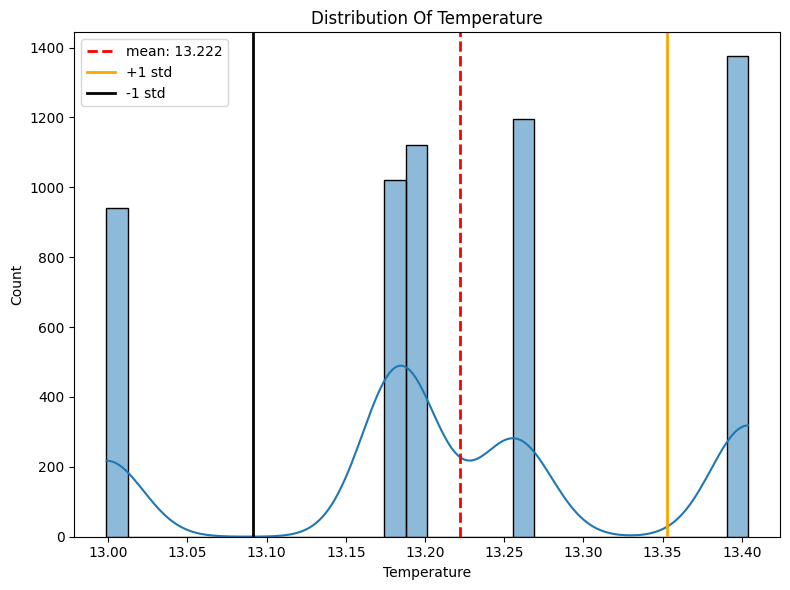

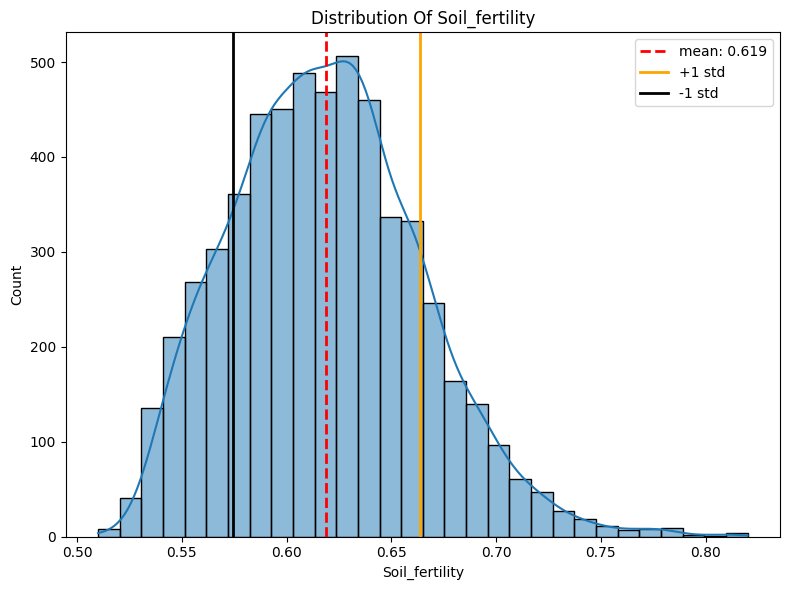

In [27]:
def plot_numerical_distribution(df, columns, title = None) -> None:
    """
    A Plot for the distribution of a numerical variables with counts.
    """
    
    mean = round(float(df[columns].mean()), 3)
    std = df[columns].std()

    fig, ax = plt.subplots(figsize = (8,6))
    sns.histplot(data = df[columns], bins=30, kde= True, ax = ax)
    ax.axvline(mean, color = "red", linewidth = 2, linestyle ="dashed", label = f"mean: {mean}")
    ax.axvline(mean + std, color = "orange", linewidth = 2, linestyle = "-", label = f"+1 std")
    ax.axvline(mean - std, color = "black", linewidth = 2, linestyle = "-", label = f"-1 std")

    ax.set_title(f"Distribution Of {columns}")
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_numerical_distribution(df, "Standard_yield")
plot_numerical_distribution(df, "Field_Rainfall")
plot_numerical_distribution(df, "Station_Rainfall")
plot_numerical_distribution(df, "Temperature")
plot_numerical_distribution(df, "Soil_fertility")

The histograms shows how the selected numerical variable is distributed around its mean, with the spread of values captured by the standard deviation lines. Most observations cluster near the center, while a longer tail or slight skewness suggests that a few values are unusually low or high. This indicates variability in the underlying feature and may point to the presence of outliers or influential observations

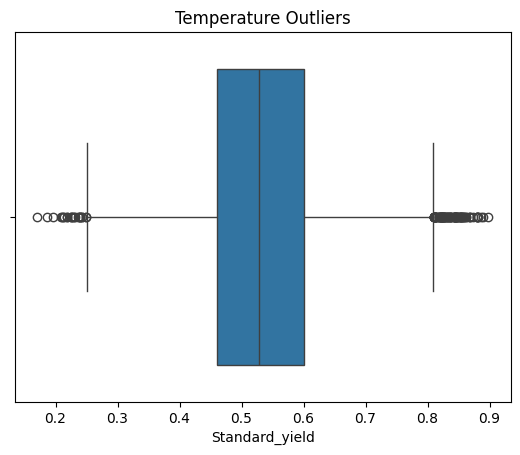

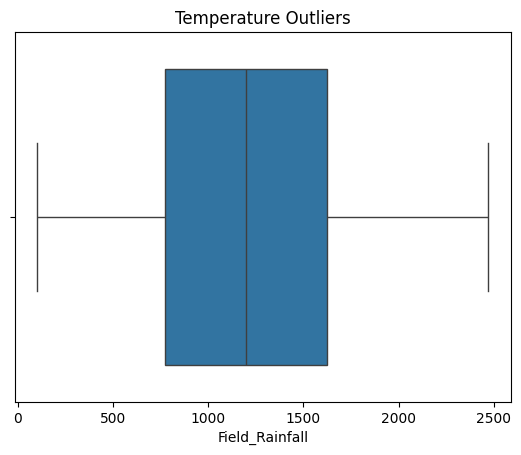

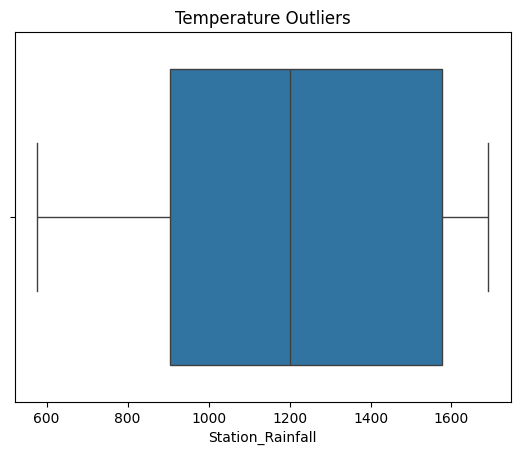

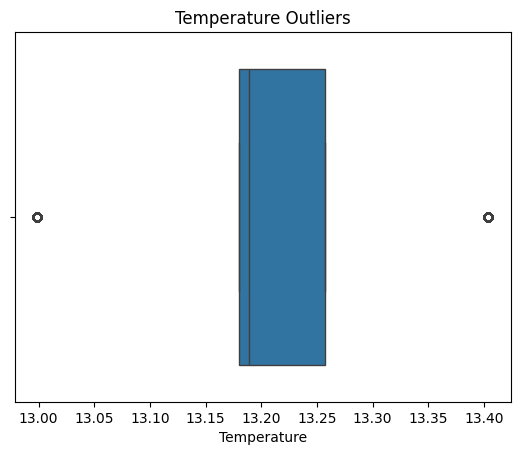

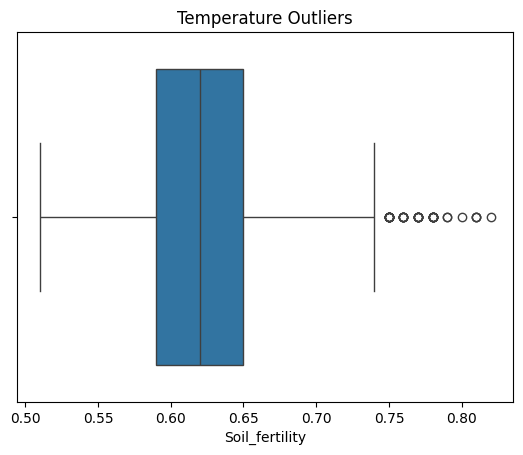

In [28]:
def numerical_outlier_detection(df, columns, title = None) -> None:
    plt.Figure(figsize=(8, 6))
    sns.boxplot(data = df, x = df[columns])
    plt.title("Temperature Outliers")
    plt.show()
numerical_outlier_detection(df, "Standard_yield")
numerical_outlier_detection(df, "Field_Rainfall")
numerical_outlier_detection(df, "Station_Rainfall")
numerical_outlier_detection(df, "Temperature")
numerical_outlier_detection(df, "Soil_fertility")


## Part 2: Categorical Variables

In [29]:
get_categorical_columns(df)

,categorical_columns
0,Location
1,Soil_type
2,Crop_type


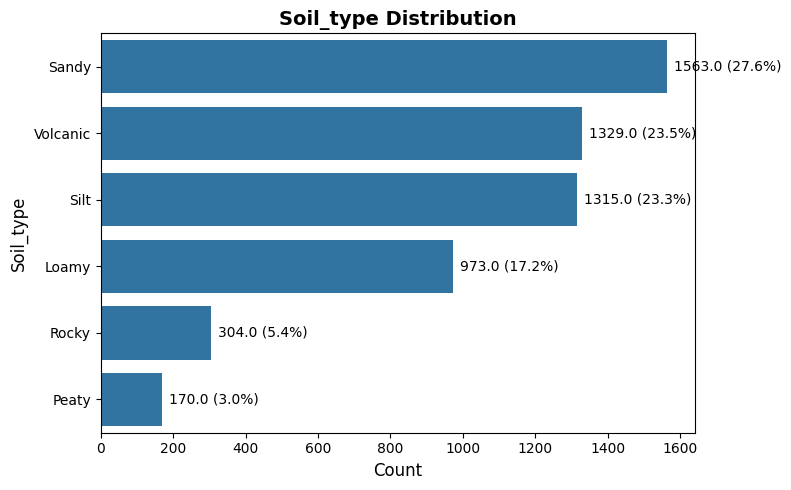

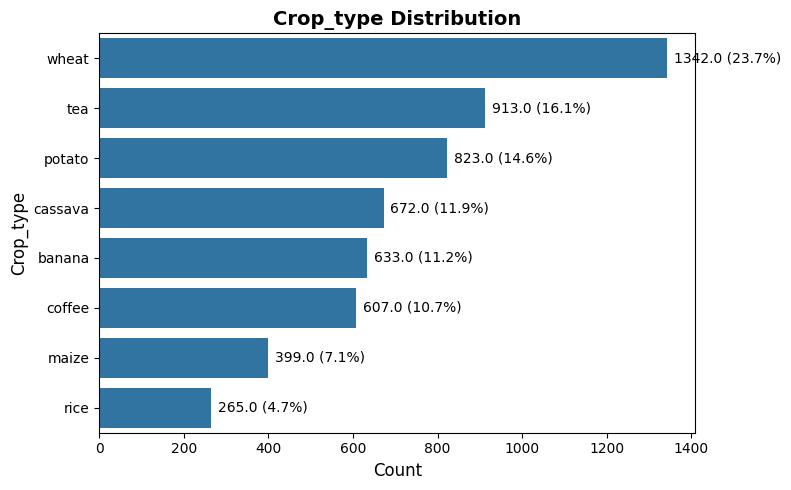

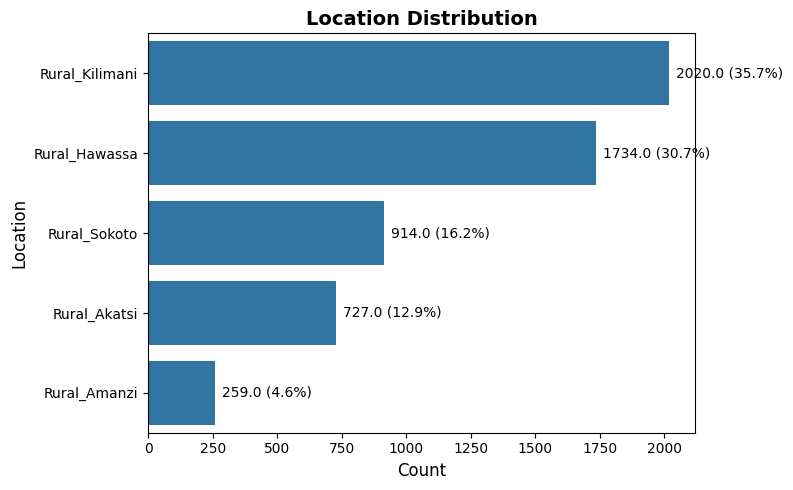

In [30]:
def plot_categorical_distribution(df, column, title=None) -> None:
    """
    A Plot for the distribution of a categorical variables with counts and percentages.
    """
    if title is None:
        title = f"{column} Distribution"

    plt.figure(figsize=(8, 5))
    ax = sns.countplot(
        data=df, 
        y=column, 
        order=df[column].value_counts().index)
    
    ax.bar_label( 
        ax.containers[0], 
        labels=[f'{val} ({val/len(df)*100:.1f}%)' for val in ax.containers[0].datavalues], 
        padding=5)
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Count", fontsize=12)
    plt.ylabel(column, fontsize=12)
    plt.tight_layout()
    plt.show()
    
plot_categorical_distribution(df, "Soil_type")
plot_categorical_distribution(df, "Crop_type")
plot_categorical_distribution(df, "Location")

The categorical distribution plots show that the dataset is unevenly distributed across categories, with some soil types, crop types, and locations appearing more frequently than others. This imbalance suggests that certain classes are better represented in the data, which may influence the reliability and generalizability of downstream analysis and modeling